# Six-Face Test: Calibration

Use this notebook to compute the calibration parameters with the data from the `1-dataCapture.ipynb` notebook.

## Setup

In [1]:
from signal_utils import IMUSampleReader, IMUSampleTimeSeriesPlotter
import numpy as np

G = 9.80665

reader = IMUSampleReader()
captureFiles = [
    "./capture/positive-x-up.csv",
    "./capture/negative-x-up.csv",
    "./capture/positive-y-up.csv",
    "./capture/negative-y-up.csv",
    "./capture/positive-z-up.csv",
    "./capture/negative-z-up.csv",
]
rawOrientations = [reader.read(file) for file in captureFiles]

timeSeriesPlotter = IMUSampleTimeSeriesPlotter()

## Accelerometer 
View accelerometer calibration as an affine transformation (rotation, shear, scaling, translation) applied to the raw sensor data to obtain the true physical values. Consider the linear system:

Ax = b 

Where:
- A: the mean of raw sensor readings in the six static orientations. This is valid since standard deviations are tight overall, as seen in `2-analysis.ipynb`.
- b: true physical values (0 or +-g, depending on the axis and orientation).
- x: transformation matrix obtained with least squares by multiplying the pseudo-inverse of A and b i.e. x = (A^t * A)^(-1) * A^t * b.

Alternatives:
- Just substracting the bias (mean of each axis across all orientations) from the raw data. Too simple and maybe error prone.
- Using the current approach with many linear transformations for at least two known temparatures and use interpolation to get the parameters for any temperature. Feasible since the IMU measures temperature too, I can craft another device for temperature measurement with my Arduino Uno and a DHT11 sensor and can use a heater from home. Much more work and maybe the difference is not significant enough to justify it.
- Using some non-linear transformation. More precise but much more complex.

Sources: 
- https://cookierobotics.com/061/
- Linear Algebra - Stanley Grossman: 6.2. Approximation by Least Squares

In [2]:
A = np.ones((len(captureFiles), 4))
for i, rawMotionData in enumerate(rawOrientations):
    ax = np.mean(rawMotionData["a"]["x"])  # type: ignore
    ay = np.mean(rawMotionData["a"]["y"])  # type: ignore
    az = np.mean(rawMotionData["a"]["z"])  # type: ignore

    # 1: independent term for bias
    A[i] = [ax, ay, az, 1]
print(f"A = {A}")

b = np.zeros((len(captureFiles), 3))
b[0][0] = G
b[1][0] = -G
b[2][1] = G
b[3][1] = -G
b[4][2] = G
b[5][2] = -G
print(f"\nb = {b}")

x = np.linalg.pinv(A) @ b
print(f"\nx = {x}")

A = [[ 1.01286745e+01  3.59638602e-01 -1.39074787e-01  1.00000000e+00]
 [-9.50094318e+00  1.78156346e-01  2.66360134e-01  1.00000000e+00]
 [ 2.15340301e-01  9.99934483e+00  3.45716596e-01  1.00000000e+00]
 [ 4.48391050e-01 -9.66972923e+00 -3.56969945e-02  1.00000000e+00]
 [ 4.64882463e-01  1.33724347e-01  1.02007694e+01  1.00000000e+00]
 [ 2.03726083e-01 -5.97101520e-04 -9.79886913e+00  1.00000000e+00]]

b = [[ 9.80665  0.       0.     ]
 [-9.80665  0.       0.     ]
 [ 0.       9.80665  0.     ]
 [ 0.      -9.80665  0.     ]
 [ 0.       0.       9.80665]
 [ 0.       0.      -9.80665]]

x = [[ 0.99878374 -0.00933288  0.02040961]
 [ 0.01210606  0.99696514 -0.01862394]
 [-0.01313606 -0.00642989  0.98043959]
 [-0.32646267 -0.16230203 -0.1406934 ]]


## Gyroscope

For the gyroscope, I can only substract the stationary bias for now, since I can't produce known angular velocities for calibration. 

Alternatives:
- Craft another device with my Arduino Uno, a stepper motor and some 3D-printed parts to make a rotating platform. Feasible but much more work.
- Same approaches listed on the accelerometer section.


In [3]:
rollBias = np.mean(np.concatenate([rawMotionData["w"]["roll"] for rawMotionData in rawOrientations]))  # type: ignore
pitchBias = np.mean(np.concatenate([rawMotionData["w"]["pitch"] for rawMotionData in rawOrientations]))  # type: ignore
yawBias = np.mean(np.concatenate([rawMotionData["w"]["yaw"] for rawMotionData in rawOrientations]))  # type: ignore

print(f"rollBias = {rollBias}")
print(f"pitchBias = {pitchBias}")
print(f"yawBias = {yawBias}")

rollBias = -5.133701801300049
pitchBias = 3.226569890975952
yawBias = -1.397046685218811


## Results

In [4]:
calibratedOrientations = []
for rawMotionData in rawOrientations:

    timespan = len(rawMotionData["seq"])
    ax = np.zeros(timespan)
    ay = np.zeros(timespan)
    az = np.zeros(timespan)

    for j in range(timespan):
        ax[j] = np.dot(np.array([rawMotionData["a"]["x"][j], rawMotionData["a"]["y"][j], rawMotionData["a"]["z"][j], 1]), x.T[0])  # type: ignore
        ay[j] = np.dot(np.array([rawMotionData["a"]["x"][j], rawMotionData["a"]["y"][j], rawMotionData["a"]["z"][j], 1]), x.T[1])  # type: ignore
        az[j] = np.dot(np.array([rawMotionData["a"]["x"][j], rawMotionData["a"]["y"][j], rawMotionData["a"]["z"][j], 1]), x.T[2])  # type: ignore

    calibratedOrientations.append(
        {
            "seq": rawMotionData["seq"],
            "a": {
                "x": ax,
                "y": ay,
                "z": az,
            },
            "w": {
                "roll": rawMotionData["w"]["roll"] - rollBias,  # type: ignore
                "pitch": rawMotionData["w"]["pitch"] - pitchBias,  # type: ignore
                "yaw": rawMotionData["w"]["yaw"] - yawBias,  # type: ignore
            },
        }
    )

### Orientation 1: +X Up

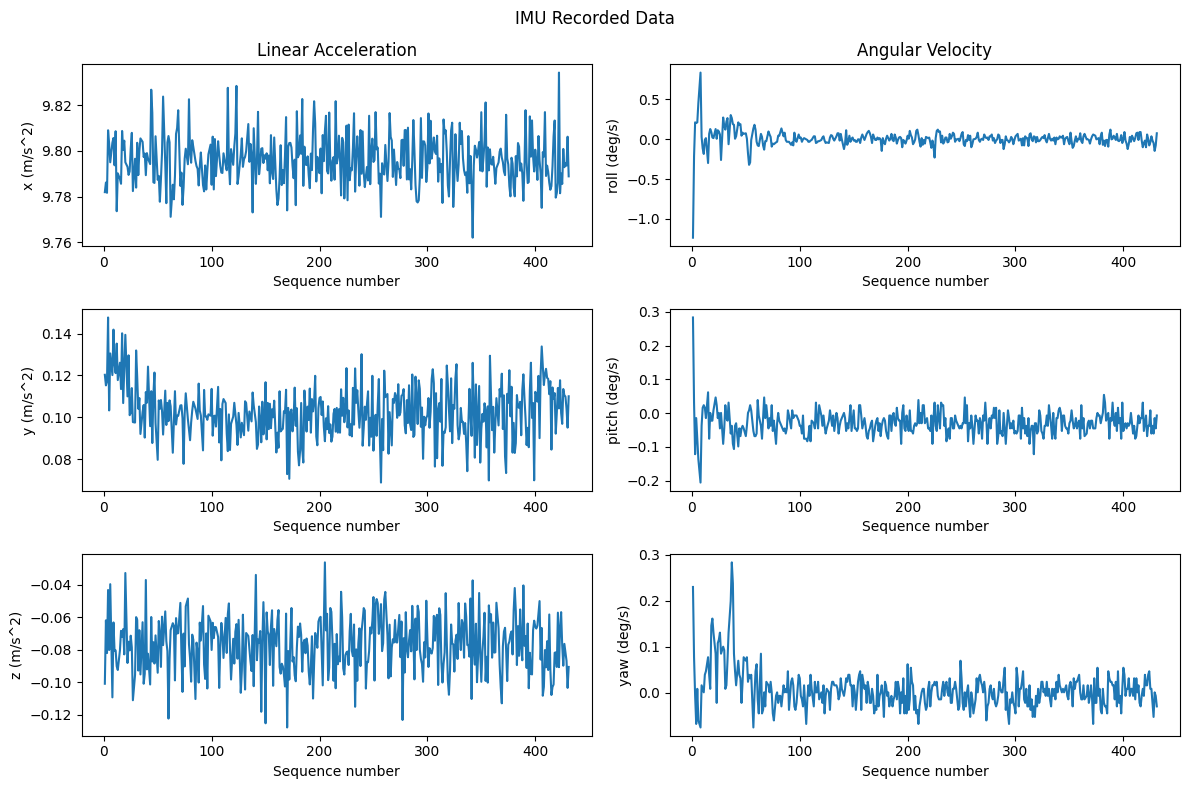

In [5]:
timeSeriesPlotter.plot(calibratedOrientations[0])  # type: ignore

### Orientation 2: -X Up

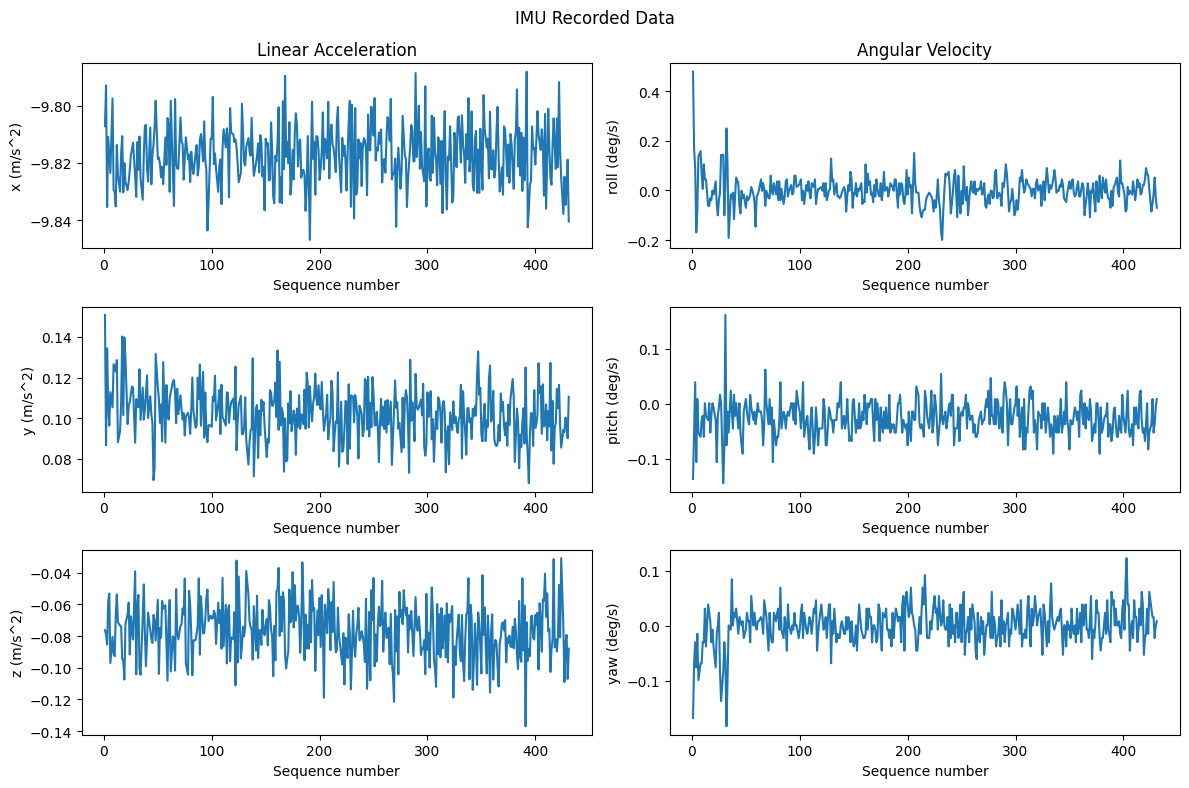

In [6]:
timeSeriesPlotter.plot(calibratedOrientations[1])  # type: ignore

### Orientation 3: +Y Up

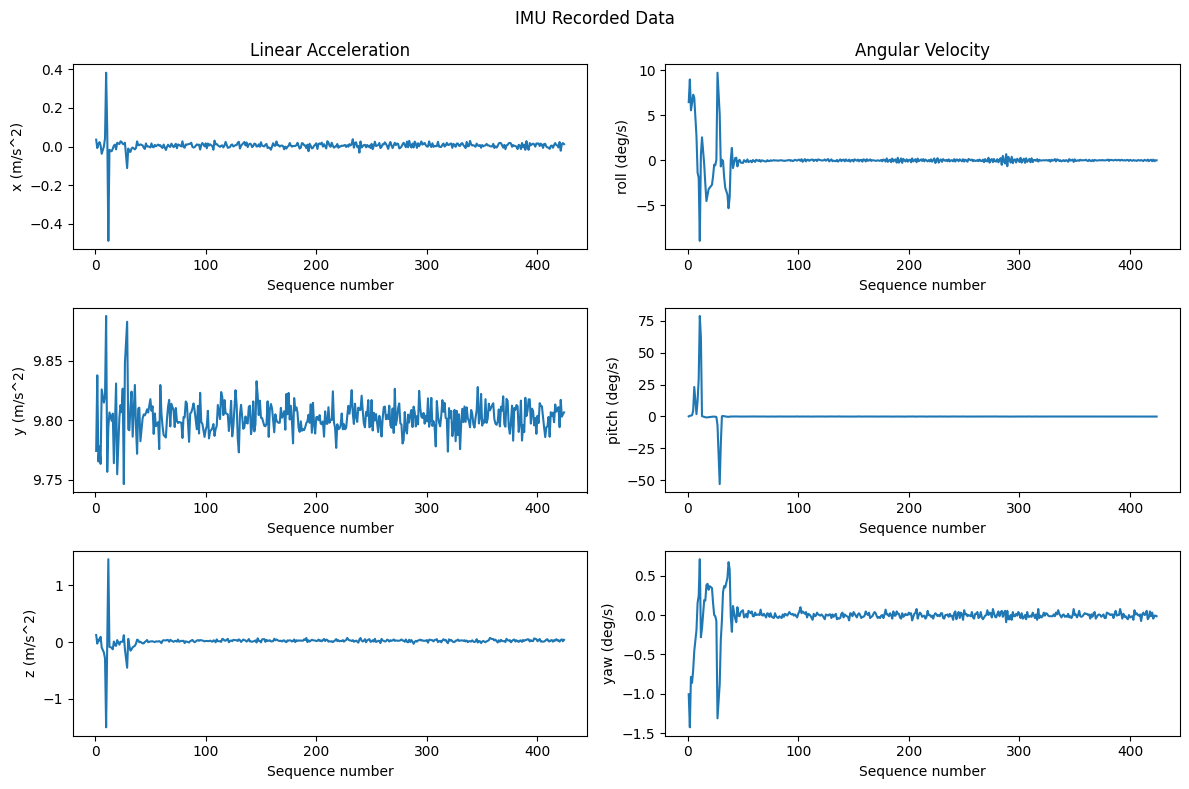

In [7]:
timeSeriesPlotter.plot(calibratedOrientations[2])  # type: ignore

### Orientation 4: -Y Up

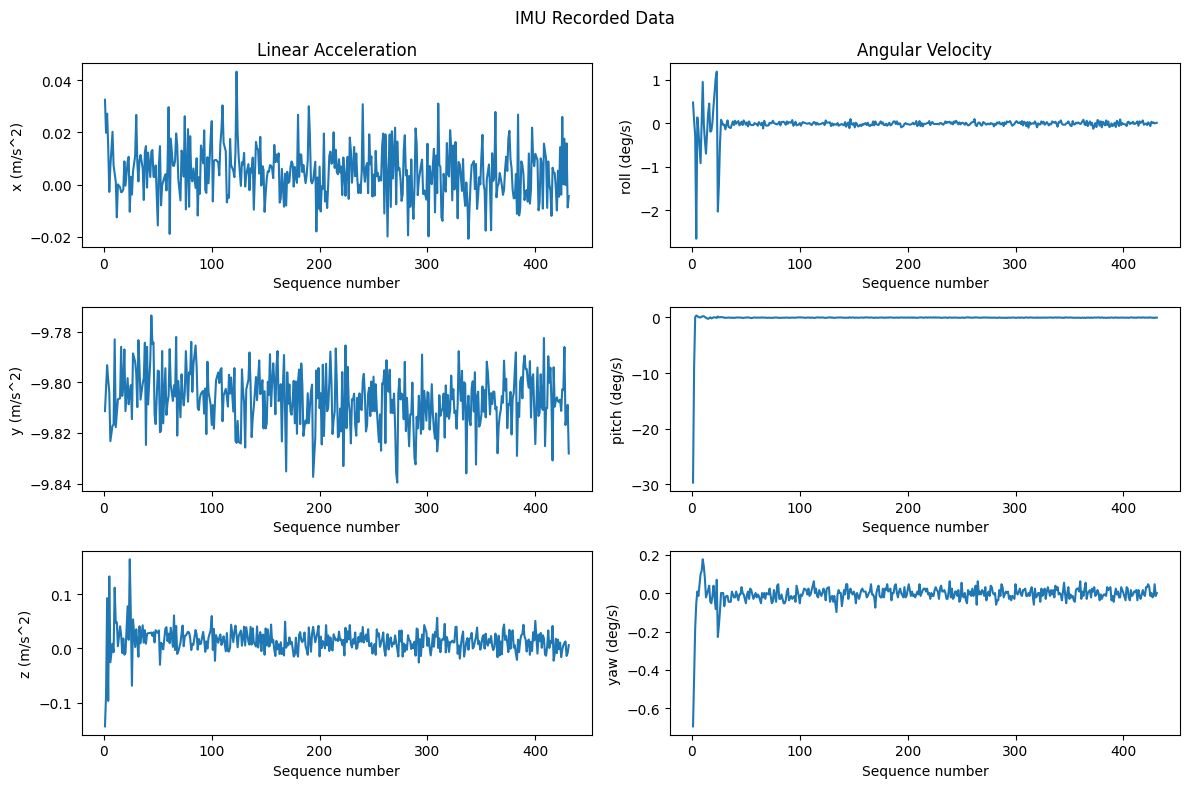

In [8]:
timeSeriesPlotter.plot(calibratedOrientations[3])  # type: ignore

### Orientation 5: +Z Up

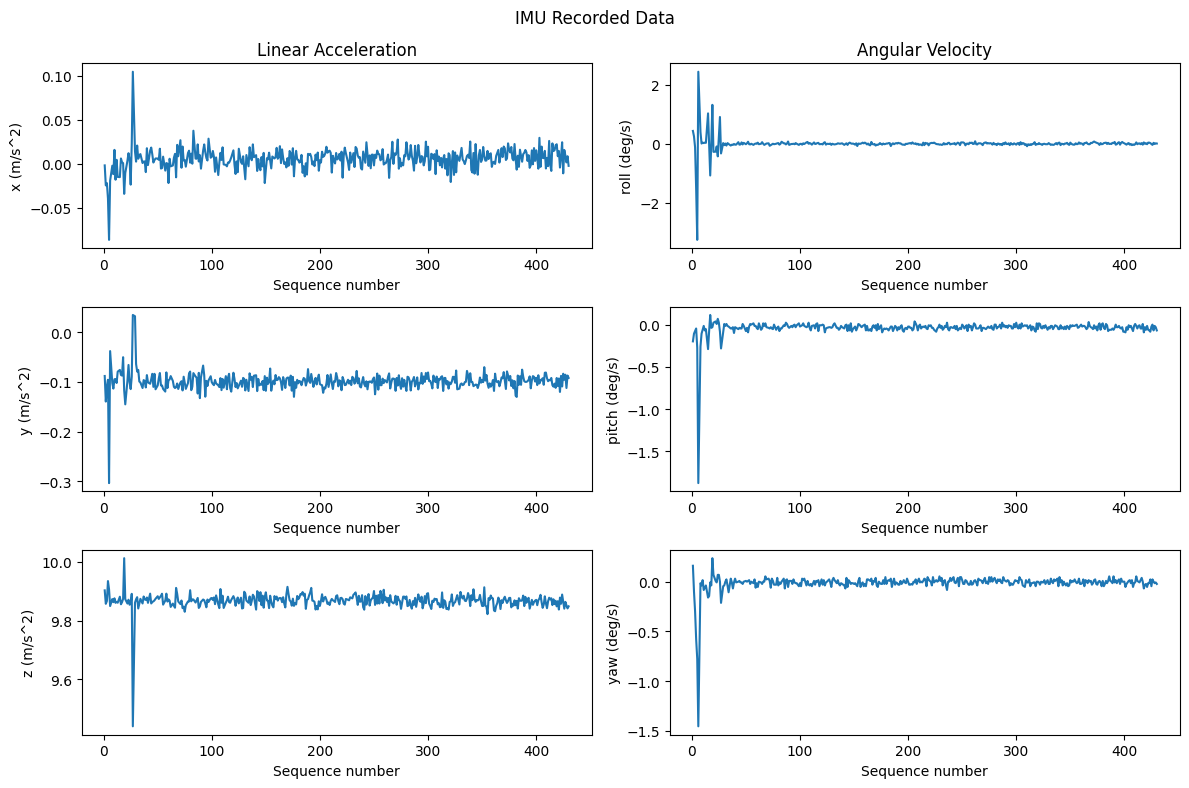

In [9]:
timeSeriesPlotter.plot(calibratedOrientations[4])  # type: ignore

### Orientation 6: -Z Up

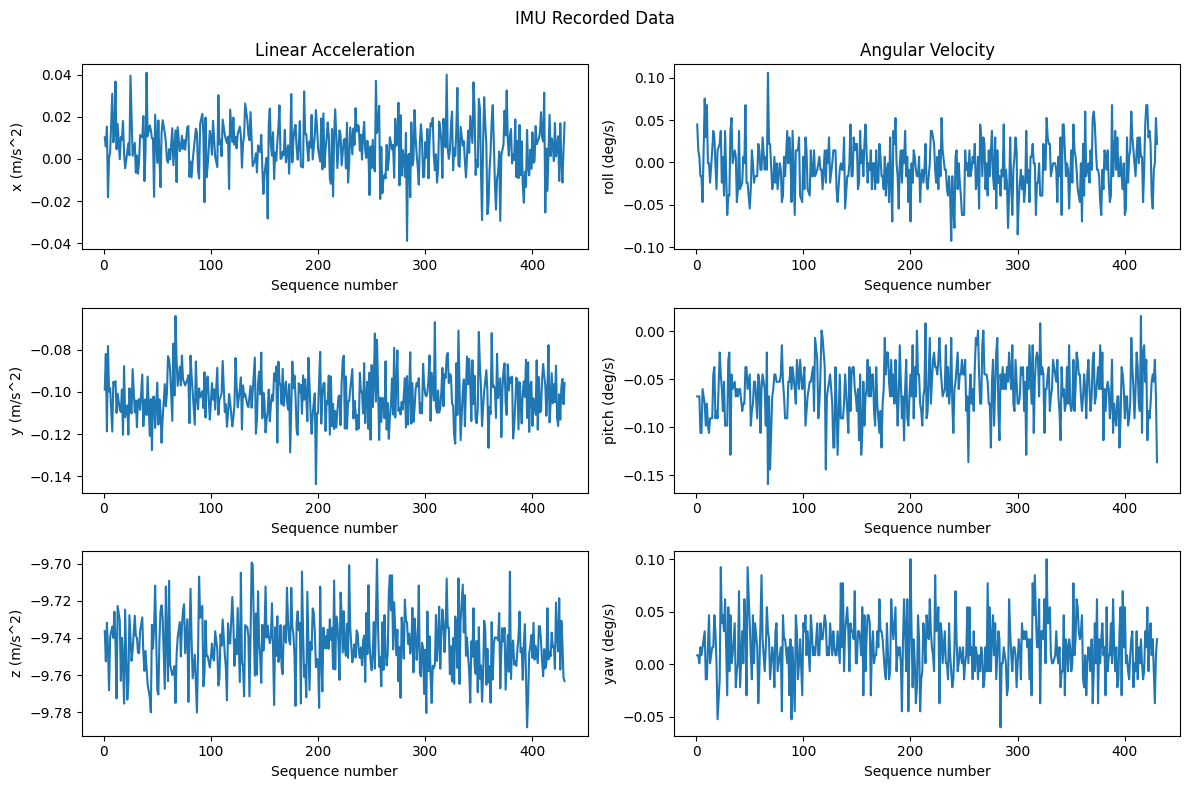

In [10]:
timeSeriesPlotter.plot(calibratedOrientations[5])  # type: ignore

## Sample data for test case

In [11]:
ax = rawOrientations[0]["a"]["x"]  # type: ignore
ay = rawOrientations[0]["a"]["y"]  # type: ignore
az = rawOrientations[0]["a"]["z"]  # type: ignore
roll = rawOrientations[0]["w"]["roll"]  # type: ignore
pitch = rawOrientations[0]["w"]["pitch"]  # type: ignore
yaw = rawOrientations[0]["w"]["yaw"]  # type: ignore
print(
    "\nSample values for X-axis up orientation test:\n",
    f"ax: {ax[len(ax) // 2]: .4f}, ay: {ay[len(ay) // 2]: .4f}, az: {az[len(az) // 2]: .4f},",
    f"roll: {roll[len(roll) // 2]: .4f}, pitch: {pitch[len(pitch) // 2]: .4f}, yaw: {yaw[len(yaw) // 2]: .4f},",
    "seq=*"
    "\nAssert that: |x - tol| <= g, |y - tol| <= 0, |z - tol| <= 0, seq remains equal",
)

ax = rawOrientations[2]["a"]["x"]  # type: ignore
ay = rawOrientations[2]["a"]["y"]  # type: ignore
az = rawOrientations[2]["a"]["z"]  # type: ignore
roll = rawOrientations[2]["w"]["roll"]  # type: ignore
pitch = rawOrientations[2]["w"]["pitch"]  # type: ignore
yaw = rawOrientations[2]["w"]["yaw"]  # type: ignore
print(
    "\nSample raw values for Y-axis up orientation test:\n",
    f"ax: {ax[len(ax) // 2]: .4f}, ay: {ay[len(ay) // 2]: .4f}, az: {az[len(az) // 2]: .4f},",
    f"roll: {roll[len(roll) // 2]: .4f}, pitch: {pitch[len(pitch) // 2]: .4f}, yaw: {yaw[len(yaw) // 2]: .4f},",
    f"seq=*"
    "\nAssert that: |x - tol| <= 0, |y - tol| <= g, |z - tol| <= 0, seq remains equal",
)

ax = rawOrientations[4]["a"]["x"]  # type: ignore
ay = rawOrientations[4]["a"]["y"]  # type: ignore
az = rawOrientations[4]["a"]["z"]  # type: ignore
roll = rawOrientations[4]["w"]["roll"]  # type: ignore
pitch = rawOrientations[4]["w"]["pitch"]  # type: ignore
yaw = rawOrientations[4]["w"]["yaw"]  # type: ignore
print(
    "\nSample raw values for Z-axis up orientation test:\n",
    f"ax: {ax[len(ax) // 2]: .4f}, ay: {ay[len(ay) // 2]: .4f}, az: {az[len(az) // 2]: .4f},",
    f"roll: {roll[len(roll) // 2]: .4f}, pitch: {pitch[len(pitch) // 2]: .4f}, yaw: {yaw[len(yaw) // 2]: .4f},",
    "seq=*"
    "\nAssert that: |x - tol| <= 0, |y - tol| <= 0, |z - tol| <= g, seq remains equal",
)


Sample values for X-axis up orientation test:
 ax:  10.1110, ay:  0.3520, az: -0.1431, roll: -5.1195, pitch:  3.1892, yaw: -1.3810, seq=*
Assert that: |x - tol| <= g, |y - tol| <= 0, |z - tol| <= 0, seq remains equal

Sample raw values for Y-axis up orientation test:
 ax:  0.2107, ay:  9.9925, az:  0.3478, roll: -5.1195, pitch:  3.1587, yaw: -1.4420, seq=*
Assert that: |x - tol| <= 0, |y - tol| <= g, |z - tol| <= 0, seq remains equal

Sample raw values for Z-axis up orientation test:
 ax:  0.4609, ay:  0.1371, az:  10.2044, roll: -5.1424, pitch:  3.1434, yaw: -1.3810, seq=*
Assert that: |x - tol| <= 0, |y - tol| <= 0, |z - tol| <= g, seq remains equal
